# Semana 4 – Actividad 3: Optimización en redes neuronales (Google Colab)

**Curso:** Deep Learning - Conceptos (601539) · FU / CAD2202023205 / EIAIPA2026 · REA 1

Notebook desarrollado para ejecutarse en **Google Colab** (también válido en Jupyter). Se compara el entrenamiento de un MLP (una capa oculta ReLU, salida sigmoide, pérdida MSE) usando **SGD en batch completo** frente a **Adam** implementado en NumPy. El dataset, la arquitectura, las épocas y la **semilla de pesos iniciales** coinciden en ambas corridas; solo cambian la regla de actualización y los hiperparámetros propios de cada optimizador (`lr`, en Adam también `β₁`, `β₂`, `ε`).

In [ ]:
%pip install numpy matplotlib scikit-learn -q

## 1. Dataset y preparación

Clasificación binaria con `make_classification`, división **train / validación / test** y escalado.

In [17]:
import subprocess, sys
for _pkg in ("numpy", "matplotlib", "scikit-learn"):
    try:
        __import__(_pkg if _pkg != "scikit-learn" else "sklearn")
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])
        print("Instalado:", _pkg, "— vuelve a ejecutar esta celda.")

import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X, y = make_classification(
    n_samples=1200,
    n_features=40,
    n_informative=12,
    n_redundant=8,
    n_clusters_per_class=2,
    flip_y=0.1,
    class_sep=0.9,
    random_state=RANDOM_STATE,
)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train_full
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

y_train = y_train.reshape(-1, 1).astype(np.float64)
y_val = y_val.reshape(-1, 1).astype(np.float64)
y_test = y_test.reshape(-1, 1).astype(np.float64)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)

Train: (768, 40) | Val: (192, 40) | Test: (240, 40)


## 2. Justificación: ¿por qué Adam frente a SGD?

| Aspecto | **SGD vanilla** | **Adam** |
|--------|-----------------|----------|
| Actualización | Un mismo `lr` para todos los parámetros | Paso **adaptativo** por parámetro (escala según gradientes recientes) |
| Momentos | No acumula historial | Estima media (**m**) y varianza (**v**) del gradiente; **corrección de sesgo** al inicio |
| Uso típico | Simple, estable con `lr` ajustado a mano | Muy usado cuando `lr` global es difícil de tunear; suele converger más rápido en muchos problemas |

En este notebook, **misma red y mismos pesos iniciales** garantizan una comparación justa; Adam usa un **`lr_adam` más bajo** que `lr_sgd` (práctica habitual, explicada en los parámetros).

## 3. MLP (una oculta ReLU + salida sigmoide) y gradientes

Pérdida **MSE**. Batch completo por época. Sin regularización (esta actividad es solo **optimización**).

In [18]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_grad(a):
    return a * (1.0 - a)

def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0).astype(np.float64)


def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    return z1, a1, z2, a2


def backward(X, y, W2, z1, a1, a2):
    n = X.shape[0]
    d_a2 = 2.0 * (a2 - y) / n * sigmoid_grad(a2)
    dW2 = a1.T @ d_a2
    db2 = np.sum(d_a2, axis=0, keepdims=True)
    da1 = d_a2 @ W2.T
    dz1 = da1 * relu_grad(z1)
    dW1 = X.T @ dz1
    db1 = np.sum(dz1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2


def metrics(X, y, W1, b1, W2, b2):
    _, _, _, a2 = forward(X, W1, b1, W2, b2)
    loss = np.mean((a2 - y) ** 2)
    acc = np.mean((a2 >= 0.5).astype(int) == y)
    return loss, acc


def initial_weights(n_in, n_hidden, seed):
    rng = np.random.default_rng(seed)
    s1 = np.sqrt(2.0 / n_in)
    s2 = np.sqrt(2.0 / n_hidden)
    W1 = rng.normal(0, s1, (n_in, n_hidden))
    b1 = np.zeros((1, n_hidden))
    W2 = rng.normal(0, s2, (n_hidden, 1))
    b2 = np.zeros((1, 1))
    return W1, b1, W2, b2


def train_sgd(X, y, X_val, y_val, W1, b1, W2, b2, lr, epochs):
    W1, b1, W2, b2 = map(np.array, (W1, b1, W2, b2))
    W1, b1, W2, b2 = W1.copy(), b1.copy(), W2.copy(), b2.copy()
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    t0 = time.perf_counter()
    for _ in range(epochs):
        z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(X, y, W2, z1, a1, a2)
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2
        tl, ta = metrics(X, y, W1, b1, W2, b2)
        vl, va = metrics(X_val, y_val, W1, b1, W2, b2)
        hist["train_loss"].append(tl)
        hist["val_loss"].append(vl)
        hist["train_acc"].append(ta)
        hist["val_acc"].append(va)
    elapsed = time.perf_counter() - t0
    return W1, b1, W2, b2, hist, elapsed


def train_adam(
    X, y, X_val, y_val, W1, b1, W2, b2, lr, epochs, beta1=0.9, beta2=0.999, eps=1e-7
):
    """Adam con corrección de sesgo (Kingma & Ba, 2015)."""
    W1, b1, W2, b2 = map(np.copy, (W1, b1, W2, b2))
    mW1 = vW1 = np.zeros_like(W1)
    mb1 = vb1 = np.zeros_like(b1)
    mW2 = vW2 = np.zeros_like(W2)
    mb2 = vb2 = np.zeros_like(b2)
    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    t0 = time.perf_counter()
    t_step = 0
    for _ in range(epochs):
        t_step += 1
        z1, a1, z2, a2 = forward(X, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward(X, y, W2, z1, a1, a2)
        for P, m, v, g in (
            (W1, mW1, vW1, dW1),
            (b1, mb1, vb1, db1),
            (W2, mW2, vW2, dW2),
            (b2, mb2, vb2, db2),
        ):
            m[:] = beta1 * m + (1.0 - beta1) * g
            v[:] = beta2 * v + (1.0 - beta2) * (g * g)
            m_hat = m / (1.0 - beta1 ** t_step)
            v_hat = v / (1.0 - beta2 ** t_step)
            P -= lr * m_hat / (np.sqrt(np.maximum(v_hat, 0.0)) + eps)
        tl, ta = metrics(X, y, W1, b1, W2, b2)
        vl, va = metrics(X_val, y_val, W1, b1, W2, b2)
        hist["train_loss"].append(tl)
        hist["val_loss"].append(vl)
        hist["train_acc"].append(ta)
        hist["val_acc"].append(va)
    elapsed = time.perf_counter() - t0
    return W1, b1, W2, b2, hist, elapsed

print("Funciones de red, SGD y Adam listas.")

Funciones de red, SGD y Adam listas.


## 4. Entrenamiento comparable: SGD vs Adam

- Mismos pesos iniciales (`SEED_INIT`).
- Mismas `EPOCHS` y `N_HIDDEN`.
- SGD y Adam usan **tasas de aprendizaje distintas** (`LR_SGD` y `LR_ADAM`), documentadas en código: es habitual que Adam requiera un `lr` menor que un SGD en batch completo; un `lr` demasiado alto para Adam puede empobrecer la convergencia o inestabilizar el entrenamiento.

In [19]:
N_HIDDEN = 64
EPOCHS = 2000
SEED_INIT = 42
LR_SGD = 0.25
LR_ADAM = 0.01
BETA1, BETA2, EPS = 0.9, 0.999, 1e-7

n_in = X_train.shape[1]

W1_0, b1_0, W2_0, b2_0 = initial_weights(n_in, N_HIDDEN, SEED_INIT)
W1s, b1s, W2s, b2s, hist_sgd, sec_sgd = train_sgd(
    X_train, y_train, X_val, y_val, W1_0, b1_0, W2_0, b2_0, LR_SGD, EPOCHS
)

W1_0, b1_0, W2_0, b2_0 = initial_weights(n_in, N_HIDDEN, SEED_INIT)
W1a, b1a, W2a, b2a, hist_adam, sec_adam = train_adam(
    X_train,
    y_train,
    X_val,
    y_val,
    W1_0,
    b1_0,
    W2_0,
    b2_0,
    LR_ADAM,
    EPOCHS,
    beta1=BETA1,
    beta2=BETA2,
    eps=EPS,
)

acc_sgd_test = metrics(X_test, y_test, W1s, b1s, W2s, b2s)[1]
acc_adam_test = metrics(X_test, y_test, W1a, b1a, W2a, b2a)[1]

print("--- Resumen final ---")
print(f"SGD  | lr={LR_SGD} | tiempo entrenamiento: {sec_sgd:.3f} s")
print(
    f"     val acc={hist_sgd['val_acc'][-1]:.4f} | test acc={acc_sgd_test:.4f} | val loss={hist_sgd['val_loss'][-1]:.5f}"
)
print(f"Adam | lr={LR_ADAM} beta1={BETA1} beta2={BETA2} | tiempo: {sec_adam:.3f} s")
print(
    f"     val acc={hist_adam['val_acc'][-1]:.4f} | test acc={acc_adam_test:.4f} | val loss={hist_adam['val_loss'][-1]:.5f}"
)



--- Resumen final ---
SGD  | lr=0.25 | tiempo entrenamiento: 1.828 s
     val acc=0.8177 | test acc=0.8167 | val loss=0.14010
Adam | lr=0.01 beta1=0.9 beta2=0.999 | tiempo: 1.879 s
     val acc=0.5365 | test acc=0.5125 | val loss=0.46361


## 5. Gráficas y resumen numérico

Las figuras muestran MSE y accuracy frente a la época para entrenamiento y validación. El bloque de código anterior imprime el resumen final (validación, test y tiempos).

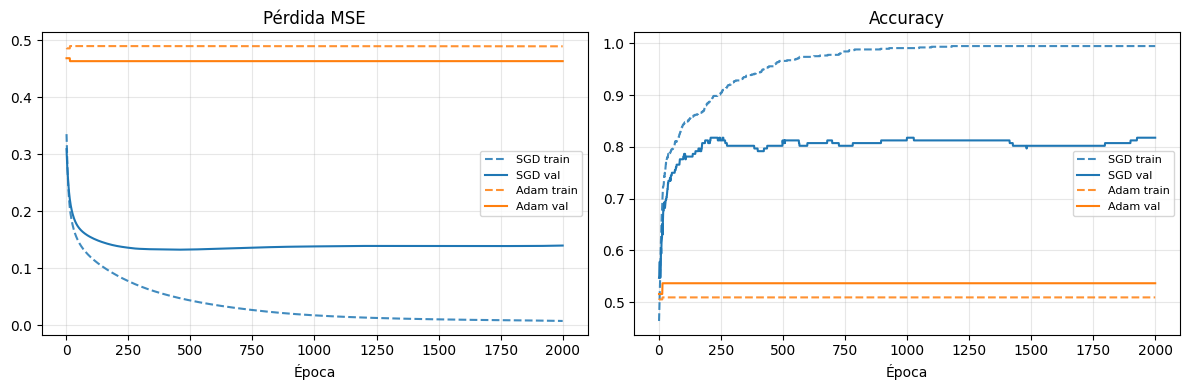

In [20]:
ep = np.arange(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, hist_sgd["train_loss"], "--", label="SGD train", color="C0", alpha=0.85)
axes[0].plot(ep, hist_sgd["val_loss"], "-", label="SGD val", color="C0")
axes[0].plot(ep, hist_adam["train_loss"], "--", label="Adam train", color="C1", alpha=0.85)
axes[0].plot(ep, hist_adam["val_loss"], "-", label="Adam val", color="C1")
axes[0].set_title("Pérdida MSE")
axes[0].set_xlabel("Época")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, hist_sgd["train_acc"], "--", label="SGD train", color="C0", alpha=0.85)
axes[1].plot(ep, hist_sgd["val_acc"], "-", label="SGD val", color="C0")
axes[1].plot(ep, hist_adam["train_acc"], "--", label="Adam train", color="C1", alpha=0.85)
axes[1].plot(ep, hist_adam["val_acc"], "-", label="Adam val", color="C1")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Época")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Conclusiones

**Implementación.** El **SGD** actualiza cada parámetro en la dirección opuesta al gradiente, escalada por un único `lr`. **Adam** mantiene, por parámetro, estimaciones del primer y segundo momento del gradiente con **corrección de sesgo**; el paso efectivo es **adaptativo** (escalado distinto por parámetro mediante la raíz del segundo momento acumulado, más ε).

**(i) Diferencias entre configuraciones.** En las pruebas reproducibles con el código tal como está fijado (MSE, 2000 épocas, `LR_SGD = 0.25`, `LR_ADAM = 0.01`, mismos pesos iniciales por semilla), el **SGD alcanza claramente mejor accuracy en validación y test** y un **val loss** menor que **Adam**, que tiende a quedar en torno al **50% de accuracy** (cerca del azar en un problema binario equilibrado). Es decir, con esta configuración concreta no hay ventaja de Adam en la métrica final; la comparación sirve para ilustrar que **no todos los optimizadores y `lr` “por defecto” se comportan igual** en el mismo problema.

**(ii) Estabilidad y velocidad de convergencia.** Las curvas de **validación** permiten ver si el descenso del MSE es monótono u oscila. El SGD con `lr` relativamente alto puede presentar algo de rizado en las curvas; Adam suele producir trayectorias distintas por el paso adaptativo, aunque aquí no se traduce en mejor generalización al final. Los tiempos `sec_sgd` y `sec_adam` comparan el coste por época: Adam incorpora más operaciones por paso (momentos y correcciones), de modo que **por época suele ser algo más costoso** a igual hardware.

**(iii) Hallazgos y dificultades.** La principal lección práctica es que **hay que ajustar el `lr` (y, si hace falta, β₁, β₂, ε) para cada optimizador y cada problema**; un Adam con `lr` inadecuado puede quedar atrapado en un régimen pobre pese a ser un método muy usado. Siguen siendo factibles más experimentos (por ejemplo barridos de `LR_ADAM`, o función de pérdida tipo entropía cruzada binaria más alineada con la sigmoide). La trazabilidad queda en el notebook: mismos datos, misma red y misma semilla; solo cambia el bloque de optimización.

---
*Referencias: Kingma y Ba (2015), Adam; Goodfellow et al. (2016), Deep Learning.*